# Mining Behavioral Risk Patterns for Diabetes Prediction
**An Explainable Ensemble Approach — CLC01 Group 9**

Pipeline:
1. Data Preparation
2. Association Rule Mining (FP-Growth) → Hypothesis Generation
3. Ensemble Classification (XGBoost + LightGBM + RF)
4. SHAP Verification → Hypothesis Confirmation/Rejection

## SETUP — Install & Import

In [25]:
import sys
import os
import warnings
import logging

# Suppress ALL warnings before any other imports
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

# Suppress jupyter_client / tornado stderr spam
logging.getLogger('jupyter_client').setLevel(logging.CRITICAL)
logging.getLogger('tornado').setLevel(logging.CRITICAL)
logging.getLogger('asyncio').setLevel(logging.CRITICAL)
logging.root.setLevel(logging.CRITICAL)

!{sys.executable} -m pip install xgboost lightgbm shap optuna imbalanced-learn mlxtend matplotlib seaborn scikit-learn --quiet 2>/dev/null
!{sys.executable} -m pip install --upgrade jupyter_client --quiet 2>/dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (recall_score, f1_score, roc_auc_score,
                              matthews_corrcoef, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from mlxtend.frequent_patterns import fpgrowth, association_rules

SEED = 42
np.random.seed(SEED)
print('Setup complete.')

The system cannot find the path specified.


Setup complete.


The system cannot find the path specified.


## SETUP — Load Data (Local)

In [26]:
import os
import warnings
warnings.filterwarnings("ignore")

# Chinh lai duong dan cho dung voi may cua ban
DATA_PATH = "./data.csv"
SAVE_PATH = "./outputs/"

os.makedirs(SAVE_PATH, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded: {df_raw.shape}")
print(f"Target distribution (raw):")
print(df_raw["Diabetes_binary"].value_counts())
df_raw.head()


Loaded: (269131, 22)
Target distribution (raw):
Diabetes_binary
0.0    194377
1.0     39657
2.0     35097
Name: count, dtype: int64


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


---
## PHASE 1 — DATA PREPARATION

### 1.1 — Binarize Target

In [27]:
df = df_raw.copy()
df['Diabetes_binary'] = df['Diabetes_binary'].apply(lambda x: 0 if x == 0.0 else 1)

counts = df['Diabetes_binary'].value_counts()
pct = df['Diabetes_binary'].value_counts(normalize=True) * 100
print('After binarization:')
print(pd.DataFrame({'Count': counts, '%': pct.round(2)}))

# Empirical justification: compare Class 1 vs Class 2 profiles
df_orig = df_raw.copy()
for cls, label in [(1.0, 'Pre-diabetes'), (2.0, 'Diabetes'), (0.0, 'No Risk')]:
    sub = df_orig[df_orig['Diabetes_binary'] == cls]
    print(f'{label}: BMI={sub["BMI"].mean():.2f}, HighBP={sub["HighBP"].mean()*100:.1f}%, PhysActivity={sub["PhysActivity"].mean()*100:.1f}%')

After binarization:
                  Count      %
Diabetes_binary               
0                194377  72.22
1                 74754  27.78
Pre-diabetes: BMI=31.83, HighBP=73.8%, PhysActivity=63.4%
Diabetes: BMI=31.96, HighBP=75.2%, PhysActivity=62.9%
No Risk: BMI=28.10, HighBP=40.1%, PhysActivity=75.2%


### 1.2 — BMI Outlier Experiment

Records with BMI > 60: 993
BMI max: 98.0
IQR Cap threshold: 42.50 (affects 11280 records)
Strategy B removed: 993 records, remaining: 268138


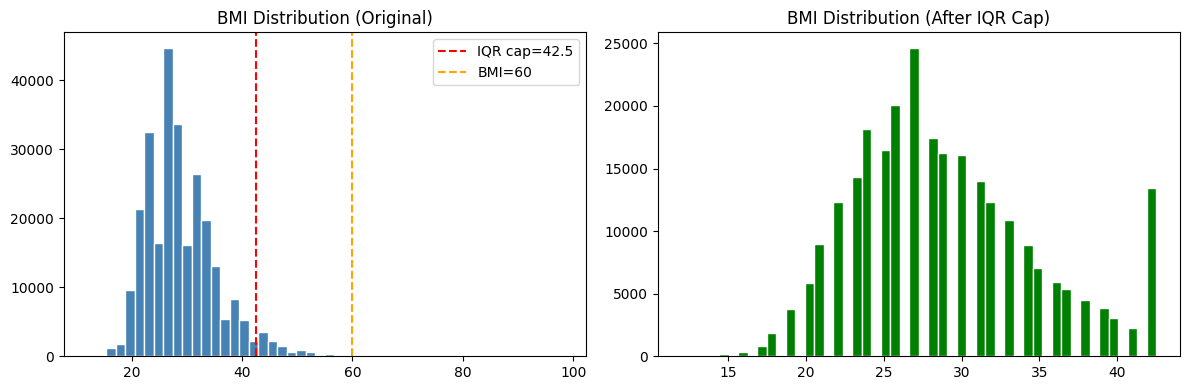

In [28]:
print(f'Records with BMI > 60: {(df["BMI"] > 60).sum()}')
print(f'BMI max: {df["BMI"].max()}')

# Strategy A: IQR Capping
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 1.5 * IQR
print(f'IQR Cap threshold: {upper_cap:.2f} (affects {(df["BMI"] > upper_cap).sum()} records)')

df_A = df.copy()
df_A['BMI'] = df_A['BMI'].clip(upper=upper_cap)

# Strategy B: Remove BMI > 60
df_B = df[df['BMI'] <= 60].copy()
print(f'Strategy B removed: {len(df) - len(df_B)} records, remaining: {len(df_B)}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['BMI'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(upper_cap, color='red', linestyle='--', label=f'IQR cap={upper_cap:.1f}')
axes[0].axvline(60, color='orange', linestyle='--', label='BMI=60')
axes[0].set_title('BMI Distribution (Original)')
axes[0].legend()
axes[1].hist(df_A['BMI'], bins=50, color='green', edgecolor='white')
axes[1].set_title('BMI Distribution (After IQR Cap)')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'bmi_distribution.png', dpi=150)
plt.show()

### 1.3 — Normalize Features (MinMaxScaler)

In [29]:
BINARY_FEATURES = ['HighBP','HighChol','CholCheck','Smoker','Stroke',
                   'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
                   'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']
SCALE_FEATURES  = ['BMI','MentHlth','PhysHlth','GenHlth','Age','Education','Income']
TARGET = 'Diabetes_binary'
ALL_FEATURES = BINARY_FEATURES + SCALE_FEATURES

# Feature sets for leakage variants
HIGH_LEAKAGE = ['GenHlth','CholCheck','DiffWalk','HeartDiseaseorAttack','Stroke']
VARIANT_B_FEATURES = [f for f in ALL_FEATURES if f not in HIGH_LEAKAGE]
VARIANT_C_FEATURES = ['PhysActivity','BMI','Smoker','Fruits','Veggies',
                       'HvyAlcoholConsump','Income','Education','Age','Sex']

scaler = MinMaxScaler()

def normalize_df(dataframe):
    d = dataframe.copy()
    d[SCALE_FEATURES] = scaler.fit_transform(d[SCALE_FEATURES])
    return d

df_A_scaled = normalize_df(df_A)
df_B_scaled = normalize_df(df_B)

print('Scaled ranges (Strategy A):')
print(df_A_scaled[SCALE_FEATURES].agg(['min','max']).round(4))

Scaled ranges (Strategy A):
     BMI  MentHlth  PhysHlth  GenHlth  Age  Education  Income
min  0.0       0.0       0.0      0.0  0.0        0.0     0.0
max  1.0       1.0       1.0      1.0  1.0        1.0     1.0


### 1.4 — Discretize Features for ARM

In [30]:
# Dùng df_A (IQR-capped, chưa scale) làm base cho ARM
df_arm = df_A.copy()

df_arm['BMI_cat']      = pd.cut(df_arm['BMI'], bins=[0,18.5,25,30,35,float('inf')],
                                 labels=['Underweight','Normal','Overweight','Obese','SeverelyObese'])
df_arm['Age_cat']      = pd.cut(df_arm['Age'], bins=[0,4,9,13],
                                 labels=['YoungAdult','MiddleAged','Senior'])
df_arm['GenHlth_cat']  = df_arm['GenHlth'].map({1:'Excellent',2:'VeryGood',3:'Good',4:'Fair',5:'Poor'})
df_arm['MentHlth_cat'] = pd.cut(df_arm['MentHlth'], bins=[0,1,14,31],
                                 labels=['None','Moderate','High'], right=False, include_lowest=True)
df_arm['PhysHlth_cat'] = pd.cut(df_arm['PhysHlth'], bins=[0,1,14,31],
                                 labels=['None','Moderate','High'], right=False, include_lowest=True)
df_arm['Income_cat']   = pd.cut(df_arm['Income'], bins=[0,3,6,8],
                                 labels=['LowIncome','MidIncome','HighIncome'])
df_arm['Education_cat']= pd.cut(df_arm['Education'], bins=[0,2,4,6],
                                 labels=['LowEdu','MidEdu','HighEdu'])

print('ARM dataset shape:', df_arm.shape)
print('Missing values:', df_arm.isnull().sum().sum())

ARM dataset shape: (269131, 29)
Missing values: 0


### 1.5 — Train/Test Split & Class Balancing Experiment

In [31]:
X = df_A_scaled[ALL_FEATURES]
y = df_A_scaled[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target dist: {y_train.value_counts().to_dict()}')

# Class balancing experiment inside CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
balancing_results = {}

for strategy_name, strategy in [('SMOTE', SMOTE(random_state=SEED)),
                                  ('NearMiss', NearMiss()),
                                  ('class_weight', None)]:
    fold_f1s = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        Xf, Xv = X_train.iloc[train_idx], X_train.iloc[val_idx]
        yf, yv = y_train.iloc[train_idx], y_train.iloc[val_idx]
        if strategy is not None:
            Xf, yf = strategy.fit_resample(Xf, yf)
            cw = None
        else:
            cw = 'balanced'
        clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight=cw)
        clf.fit(Xf, yf)
        fold_f1s.append(f1_score(yv, clf.predict(Xv), average='macro'))
    balancing_results[strategy_name] = np.mean(fold_f1s)
    print(f'{strategy_name}: mean macro F1 = {np.mean(fold_f1s):.4f}')

BEST_STRATEGY = max(balancing_results, key=balancing_results.get)
print(f'\nBest balancing strategy: {BEST_STRATEGY}')

Train: (215304, 21), Test: (53827, 21)
Train target dist: {0: 155501, 1: 59803}
SMOTE: mean macro F1 = 0.6919
NearMiss: mean macro F1 = 0.5899
class_weight: mean macro F1 = 0.6918

Best balancing strategy: SMOTE


---
## PHASE 2 — ASSOCIATION RULE MINING

### 2.1 — Build Transaction Matrix

In [32]:
# One-hot encode chỉ categorical columns, giữ nguyên binary features
cat_cols = ['BMI_cat','Age_cat','GenHlth_cat','MentHlth_cat','PhysHlth_cat','Income_cat','Education_cat']

# Binary features: giữ nguyên 0/1, không get_dummies
arm_binary_part = df_arm[BINARY_FEATURES].copy()
# Rename để rõ nghĩa trong rules
arm_binary_part.columns = [f'{c}_1' if c in BINARY_FEATURES else c for c in arm_binary_part.columns]

# Categorical features: one-hot encode
arm_cat_part = pd.get_dummies(df_arm[cat_cols].astype(str))

# Target
arm_target = pd.get_dummies(df_arm[[TARGET]].astype(str))
arm_target.rename(columns={'Diabetes_binary_0': 'NoRisk', 'Diabetes_binary_1': 'AtRisk'}, inplace=True)

# Combine
arm_encoded = pd.concat([arm_binary_part, arm_cat_part, arm_target], axis=1)

# Convert to bool for mlxtend
arm_bool = arm_encoded.astype(bool)

avg_items = arm_bool.sum(axis=1).mean()
print(f'Transaction matrix shape: {arm_bool.shape}')
print(f'Average items per transaction: {avg_items:.2f}')
print(f'Columns: {list(arm_bool.columns)}')

Transaction matrix shape: (269131, 41)
Average items per transaction: 14.45
Columns: ['HighBP_1', 'HighChol_1', 'CholCheck_1', 'Smoker_1', 'Stroke_1', 'HeartDiseaseorAttack_1', 'PhysActivity_1', 'Fruits_1', 'Veggies_1', 'HvyAlcoholConsump_1', 'AnyHealthcare_1', 'NoDocbcCost_1', 'DiffWalk_1', 'Sex_1', 'BMI_cat_Normal', 'BMI_cat_Obese', 'BMI_cat_Overweight', 'BMI_cat_SeverelyObese', 'BMI_cat_Underweight', 'Age_cat_MiddleAged', 'Age_cat_Senior', 'Age_cat_YoungAdult', 'GenHlth_cat_Excellent', 'GenHlth_cat_Fair', 'GenHlth_cat_Good', 'GenHlth_cat_Poor', 'GenHlth_cat_VeryGood', 'MentHlth_cat_High', 'MentHlth_cat_Moderate', 'MentHlth_cat_None', 'PhysHlth_cat_High', 'PhysHlth_cat_Moderate', 'PhysHlth_cat_None', 'Income_cat_HighIncome', 'Income_cat_LowIncome', 'Income_cat_MidIncome', 'Education_cat_HighEdu', 'Education_cat_LowEdu', 'Education_cat_MidEdu', 'NoRisk', 'AtRisk']


### 2.2 — Run FP-Growth

In [33]:
print('Running FP-Growth...')
# min_support=0.05 trên transaction matrix 41 cols (đã fix từ 55 cols)
# max_len=5 giới hạn độ dài rule để tránh MemoryError
frequent_itemsets = fpgrowth(arm_bool, min_support=0.05, use_colnames=True, max_len=5)
print(f'Frequent itemsets found: {len(frequent_itemsets)}')

# Generate rules với lift threshold thấp hơn để có đủ rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.5)
print(f'Rules before filtering: {len(rules)}')

# Filter: consequent = AtRisk only
rules_at_risk = rules[rules['consequents'].apply(lambda x: x == frozenset({'AtRisk'}))].copy()
print(f'Rules with consequent=AtRisk: {len(rules_at_risk)}')

# Filter: confidence >= 0.45 (base rate=0.2778, gap=+17pp — data-driven threshold)
rules_at_risk = rules_at_risk[rules_at_risk['confidence'] >= 0.45]
print(f'After confidence >= 0.45: {len(rules_at_risk)}')

# If still too many, raise thresholds further
if len(rules_at_risk) > 500:
    rules_at_risk = rules_at_risk[rules_at_risk['lift'] >= 2.0]
    print(f'After lift >= 2.0: {len(rules_at_risk)}')

Running FP-Growth...
Frequent itemsets found: 19204
Rules before filtering: 10346
Rules with consequent=AtRisk: 278
After confidence >= 0.45: 157


### 2.3 — Filter & Rank Rules

In [34]:
BASE_RATE = y.mean()  # 0.2778

def has_behavioral_feature(antecedent):
    behavioral = ['PhysActivity','BMI','Smoker','Fruits','Veggies','HvyAlcoholConsump']
    return any(any(b in item for b in behavioral) for item in antecedent)

# Filter: antecedent >= 2 features, confidence gap >= 15pp above base rate
# Note: behavioral-only filter removed — data shows clinical features dominate high-lift rules
# This is a data-driven finding consistent with proposal Section 4 (feature leakage risk)
rules_filtered = rules_at_risk[
    (rules_at_risk['antecedents'].apply(lambda x: len(x) >= 2)) &
    (rules_at_risk['confidence'] >= BASE_RATE + 0.15)
].copy()

# Tag whether rule contains behavioral feature
rules_filtered['has_behavioral'] = rules_filtered['antecedents'].apply(has_behavioral_feature)

rules_filtered = rules_filtered.sort_values('lift', ascending=False).head(20)
print(f'Top rules after filtering: {len(rules_filtered)}')

rules_display = rules_filtered[['antecedents','support','confidence','lift','has_behavioral']].copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_display['confidence_gap'] = (rules_filtered['confidence'] - BASE_RATE).round(3).values
rules_display = rules_display.round(4)
print(rules_display.to_string())
rules_display.to_csv(SAVE_PATH + 'arm_top_rules.csv', index=False)

Top rules after filtering: 20
                                                        antecedents  support  confidence    lift  has_behavioral  confidence_gap
1063                  CholCheck_1, DiffWalk_1, HighBP_1, HighChol_1   0.0628      0.6095  2.1943           False           0.332
1091              AnyHealthcare_1, DiffWalk_1, HighBP_1, HighChol_1   0.0607      0.6090  2.1924           False           0.331
1017                               DiffWalk_1, HighBP_1, HighChol_1   0.0632      0.6076  2.1876           False           0.330
2249  AnyHealthcare_1, BMI_cat_SeverelyObese, CholCheck_1, HighBP_1   0.0533      0.5899  2.1238            True           0.312
2226                   BMI_cat_SeverelyObese, CholCheck_1, HighBP_1   0.0558      0.5878  2.1161            True           0.310
2238               AnyHealthcare_1, BMI_cat_SeverelyObese, HighBP_1   0.0536      0.5875  2.1152            True           0.310
2208                                BMI_cat_SeverelyObese, HighBP_1

### 2.4 — Formulate Testable Hypotheses

In [35]:
# Map ARM item names back to original feature names for SHAP verification
# ARM uses discretized names (e.g. BMI_cat_Obese) but SHAP uses original names (e.g. BMI)
ARM_TO_ORIG = {
    'BMI_cat': 'BMI',
    'PhysActivity_1': 'PhysActivity',
    'Smoker_1': 'Smoker',
    'Fruits_1': 'Fruits',
    'Veggies_1': 'Veggies',
    'HvyAlcoholConsump_1': 'HvyAlcoholConsump',
    'Age_cat': 'Age',
    'GenHlth_cat': 'GenHlth',
    'MentHlth_cat': 'MentHlth',
    'PhysHlth_cat': 'PhysHlth',
    'Income_cat': 'Income',
    'Education_cat': 'Education',
    'HighBP_1': 'HighBP',
    'HighChol_1': 'HighChol',
    'DiffWalk_1': 'DiffWalk',
    'CholCheck_1': 'CholCheck',
    'Stroke_1': 'Stroke',
    'HeartDiseaseorAttack_1': 'HeartDiseaseorAttack',
}

BEHAVIORAL_ORIG = ['BMI', 'PhysActivity', 'Smoker', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
ALL_TESTABLE = ['BMI', 'PhysActivity', 'Smoker', 'Fruits', 'Veggies',
                'HvyAlcoholConsump', 'GenHlth', 'HighBP', 'HighChol', 'DiffWalk', 'Age']

def get_orig_feature(arm_item):
    """Map ARM item (e.g. BMI_cat_Obese) to original feature name (e.g. BMI)"""
    for prefix, orig in ARM_TO_ORIG.items():
        if arm_item.startswith(prefix):
            return orig
    return None

top10 = rules_filtered.head(10)
hypotheses = []

# Ưu tiên rules có behavioral feature trước
behavioral_rules = rules_filtered[rules_filtered['has_behavioral'] == True]
clinical_rules = rules_filtered[rules_filtered['has_behavioral'] == False]
rules_ordered = pd.concat([behavioral_rules, clinical_rules]).reset_index(drop=True)

for _, row in rules_ordered.iterrows():
    antecedent = list(row['antecedents'])
    # Find first behavioral ARM item and map to original feature
    test_arm_item = None
    test_orig_feat = None
    for item in antecedent:
        orig = get_orig_feature(item)
        if orig in ALL_TESTABLE:
            test_arm_item = item
            test_orig_feat = orig
            break
    if test_orig_feat:
        context = [x for x in antecedent if x != test_arm_item]
        h = {
            'rule': str(antecedent),
            'lift': round(row['lift'], 3),
            'confidence': round(row['confidence'], 3),
            'test_arm_item': test_arm_item,    # ARM item (e.g. BMI_cat_Obese)
            'test_orig_feat': test_orig_feat,  # Original feature for SHAP (e.g. BMI)
            'context': context,
            'hypothesis': f'In subgroup {context}, mean SHAP of [{test_orig_feat}] > population mean SHAP'
        }
        hypotheses.append(h)

# Keep max 5 unique ORIGINAL features (not ARM items)
seen_orig = set()
hypotheses_final = []
for h in hypotheses:
    if h['test_orig_feat'] not in seen_orig:
        hypotheses_final.append(h)
        seen_orig.add(h['test_orig_feat'])
    if len(hypotheses_final) == 5:
        break

print(f'Hypotheses formulated: {len(hypotheses_final)}')
for i, h in enumerate(hypotheses_final, 1):
    print(f'\nH{i}: {h["hypothesis"]}')
    print(f'     ARM item tested: {h["test_arm_item"]} → SHAP feature: {h["test_orig_feat"]}')
    print(f'     Rule lift={h["lift"]}, confidence={h["confidence"]}')

Hypotheses formulated: 4

H1: In subgroup ['AnyHealthcare_1', 'CholCheck_1', 'HighBP_1'], mean SHAP of [BMI] > population mean SHAP
     ARM item tested: BMI_cat_SeverelyObese → SHAP feature: BMI
     Rule lift=2.124, confidence=0.59

H2: In subgroup ['CholCheck_1', 'HighChol_1', 'HighBP_1'], mean SHAP of [DiffWalk] > population mean SHAP
     ARM item tested: DiffWalk_1 → SHAP feature: DiffWalk
     Rule lift=2.194, confidence=0.609

H3: In subgroup ['AnyHealthcare_1', 'CholCheck_1', 'GenHlth_cat_Fair'], mean SHAP of [HighChol] > population mean SHAP
     ARM item tested: HighChol_1 → SHAP feature: HighChol
     Rule lift=2.062, confidence=0.573

H4: In subgroup ['AnyHealthcare_1', 'CholCheck_1', 'HighBP_1'], mean SHAP of [GenHlth] > population mean SHAP
     ARM item tested: GenHlth_cat_Fair → SHAP feature: GenHlth
     Rule lift=2.049, confidence=0.569


---
## PHASE 3 — ENSEMBLE CLASSIFICATION

### 3.1 — Helper: Evaluate Model

In [36]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1] if hasattr(model, 'predict_proba') else None
    results = {
        'Model': name,
        'Recall': round(recall_score(y_te, y_pred), 4),
        'Macro_F1': round(f1_score(y_te, y_pred, average='macro'), 4),
        'AUC_ROC': round(roc_auc_score(y_te, y_prob), 4) if y_prob is not None else None,
        'MCC': round(matthews_corrcoef(y_te, y_pred), 4)
    }
    print(f"{name}: Recall={results['Recall']}, F1={results['Macro_F1']}, AUC={results['AUC_ROC']}, MCC={results['MCC']}")
    return results

def get_balanced_data(X_tr, y_tr, strategy):
    if strategy == 'SMOTE':
        return SMOTE(random_state=SEED).fit_resample(X_tr, y_tr)
    elif strategy == 'NearMiss':
        return NearMiss().fit_resample(X_tr, y_tr)
    else:  # class_weight handled in model
        return X_tr, y_tr

cw = 'balanced' if BEST_STRATEGY == 'class_weight' else None
X_tr_bal, y_tr_bal = get_balanced_data(X_train, y_train, BEST_STRATEGY)
print(f'Using strategy: {BEST_STRATEGY}')
print(f'Balanced train shape: {X_tr_bal.shape}')

Using strategy: SMOTE
Balanced train shape: (311002, 21)


### 3.2 — Baselines

In [37]:
all_results = []

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight=cw)
all_results.append(evaluate_model(lr, X_tr_bal, y_tr_bal, X_test, y_test, 'LogisticRegression'))

# Decision Tree
dt = DecisionTreeClassifier(random_state=SEED, class_weight=cw)
all_results.append(evaluate_model(dt, X_tr_bal, y_tr_bal, X_test, y_test, 'DecisionTree'))

LogisticRegression: Recall=0.7458, F1=0.6941, AUC=0.807, MCC=0.4189
DecisionTree: Recall=0.7925, F1=0.7839, AUC=0.8215, MCC=0.578


### 3.3 — Optuna Tuning: XGBoost

In [38]:
import time

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight': scale_pos,
        'random_state': SEED, 'eval_metric': 'logloss', 'use_label_encoder': False
    }
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        Xf, Xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        yf, yv = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        Xf, yf = get_balanced_data(Xf, yf, BEST_STRATEGY)
        m = xgb.XGBClassifier(**params)
        m.fit(Xf, yf, verbose=False)
        scores.append(f1_score(yv, m.predict(Xv), average='macro'))
    return np.mean(scores)

print('Tuning XGBoost...')
t0 = time.time()
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)
print(f'XGBoost best F1: {study_xgb.best_value:.4f} ({time.time()-t0:.0f}s)')

best_xgb = xgb.XGBClassifier(**study_xgb.best_params,
                               scale_pos_weight=scale_pos,
                               random_state=SEED, eval_metric='logloss',
                               use_label_encoder=False)
all_results.append(evaluate_model(best_xgb, X_tr_bal, y_tr_bal, X_test, y_test, 'XGBoost_tuned'))

Tuning XGBoost...
XGBoost best F1: 0.7242 (1126s)
XGBoost_tuned: Recall=0.8138, F1=0.7303, AUC=0.8481, MCC=0.4958


### 3.4 — Optuna Tuning: LightGBM

In [39]:
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced', 'random_state': SEED, 'verbose': -1
    }
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        Xf, Xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        yf, yv = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        Xf, yf = get_balanced_data(Xf, yf, BEST_STRATEGY)
        m = lgb.LGBMClassifier(**params)
        m.fit(Xf, yf)
        scores.append(f1_score(yv, m.predict(Xv), average='macro'))
    return np.mean(scores)

print('Tuning LightGBM...')
t0 = time.time()
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=50)
print(f'LightGBM best F1: {study_lgb.best_value:.4f} ({time.time()-t0:.0f}s)')

best_lgb = lgb.LGBMClassifier(**study_lgb.best_params,
                                class_weight='balanced', random_state=SEED,
                                verbose=-1)
all_results.append(evaluate_model(best_lgb, X_tr_bal, y_tr_bal, X_test, y_test, 'LightGBM_tuned'))

Tuning LightGBM...
LightGBM best F1: 0.7088 (635s)
LightGBM_tuned: Recall=0.6133, F1=0.7109, AUC=0.8141, MCC=0.4228


### 3.5 — Optuna Tuning: Random Forest

In [40]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt','log2']),
        'class_weight': 'balanced', 'random_state': SEED
    }
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        Xf, Xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        yf, yv = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        Xf, yf = get_balanced_data(Xf, yf, BEST_STRATEGY)
        m = RandomForestClassifier(**params)
        m.fit(Xf, yf)
        scores.append(f1_score(yv, m.predict(Xv), average='macro'))
    return np.mean(scores)

print('Tuning Random Forest...')
t0 = time.time()
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)
print(f'RF best F1: {study_rf.best_value:.4f} ({time.time()-t0:.0f}s)')

best_rf = RandomForestClassifier(**study_rf.best_params,
                                  class_weight='balanced', random_state=SEED)
all_results.append(evaluate_model(best_rf, X_tr_bal, y_tr_bal, X_test, y_test, 'RandomForest_tuned'))

Tuning Random Forest...
RF best F1: 0.7149 (10573s)
RandomForest_tuned: Recall=0.7, F1=0.7171, AUC=0.8235, MCC=0.4454


### 3.6 — Soft Voting Ensemble

In [41]:
# Refit all three on balanced training data
best_xgb.fit(X_tr_bal, y_tr_bal)
best_lgb.fit(X_tr_bal, y_tr_bal)
best_rf.fit(X_tr_bal, y_tr_bal)

voting = VotingClassifier(
    estimators=[('xgb', best_xgb), ('lgb', best_lgb), ('rf', best_rf)],
    voting='soft'
)
all_results.append(evaluate_model(voting, X_tr_bal, y_tr_bal, X_test, y_test, 'SoftVoting'))

# Save checkpoint
import pickle
with open(SAVE_PATH + 'best_xgb.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
print('XGBoost model saved to Drive.')

SoftVoting: Recall=0.7328, F1=0.7336, AUC=0.8441, MCC=0.4801
XGBoost model saved to Drive.


### 3.7 — Leakage Sensitivity: Variants A/B/C

In [42]:
leakage_results = []

for variant_name, feat_cols in [('Variant_A_full', ALL_FEATURES),
                                  ('Variant_B_no_leakage', VARIANT_B_FEATURES),
                                  ('Variant_C_behavioral_only', VARIANT_C_FEATURES)]:
    Xv_tr = X_train[feat_cols]
    Xv_te = X_test[feat_cols]
    Xv_tr_bal, yv_tr_bal = get_balanced_data(Xv_tr, y_train, BEST_STRATEGY)
    m = xgb.XGBClassifier(
        **{k: v for k, v in study_xgb.best_params.items()},
        scale_pos_weight=scale_pos, random_state=SEED,
        eval_metric='logloss', use_label_encoder=False
    )
    res = evaluate_model(m, Xv_tr_bal, yv_tr_bal, Xv_te, y_test, variant_name)
    leakage_results.append(res)

leakage_df = pd.DataFrame(leakage_results)
print('\nLeakage Sensitivity Results:')
print(leakage_df.to_string(index=False))
leakage_df.to_csv(SAVE_PATH + 'leakage_sensitivity.csv', index=False)

Variant_A_full: Recall=0.8138, F1=0.7303, AUC=0.8481, MCC=0.4958
Variant_B_no_leakage: Recall=0.8066, F1=0.7038, AUC=0.8247, MCC=0.4532
Variant_C_behavioral_only: Recall=0.8375, F1=0.6118, AUC=0.7594, MCC=0.3395

Leakage Sensitivity Results:
                    Model  Recall  Macro_F1  AUC_ROC    MCC
           Variant_A_full  0.8138    0.7303   0.8481 0.4958
     Variant_B_no_leakage  0.8066    0.7038   0.8247 0.4532
Variant_C_behavioral_only  0.8375    0.6118   0.7594 0.3395


### 3.8 — Model Comparison Table


=== FULL MODEL COMPARISON ===
             Model  Recall  Macro_F1  AUC_ROC    MCC
LogisticRegression  0.7458    0.6941   0.8070 0.4189
      DecisionTree  0.7925    0.7839   0.8215 0.5780
     XGBoost_tuned  0.8138    0.7303   0.8481 0.4958
    LightGBM_tuned  0.6133    0.7109   0.8141 0.4228
RandomForest_tuned  0.7000    0.7171   0.8235 0.4454
        SoftVoting  0.7328    0.7336   0.8441 0.4801


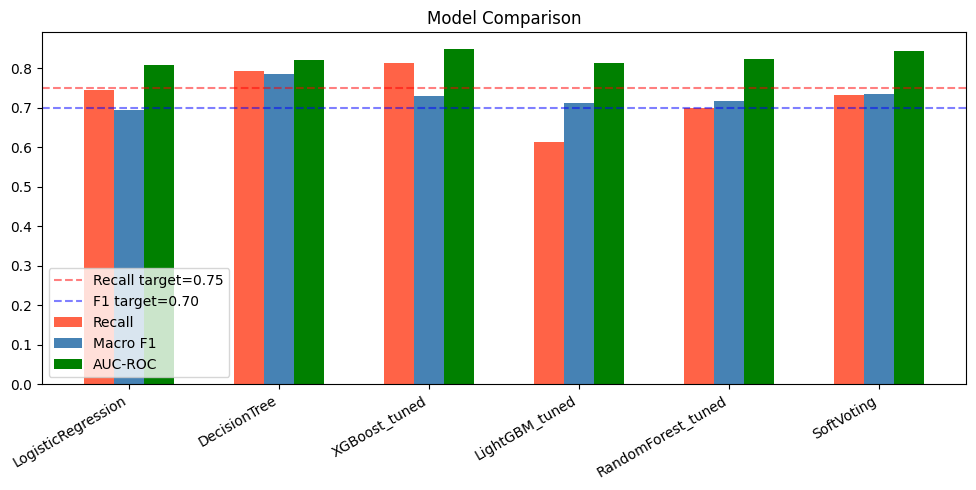

In [43]:
results_df = pd.DataFrame(all_results)
print('\n=== FULL MODEL COMPARISON ===')
print(results_df.to_string(index=False))
results_df.to_csv(SAVE_PATH + 'model_comparison.csv', index=False)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
w = 0.2
ax.bar(x - w, results_df['Recall'], w, label='Recall', color='tomato')
ax.bar(x, results_df['Macro_F1'], w, label='Macro F1', color='steelblue')
ax.bar(x + w, results_df['AUC_ROC'], w, label='AUC-ROC', color='green')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right')
ax.axhline(0.75, color='red', linestyle='--', alpha=0.5, label='Recall target=0.75')
ax.axhline(0.70, color='blue', linestyle='--', alpha=0.5, label='F1 target=0.70')
ax.legend()
ax.set_title('Model Comparison')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'model_comparison.png', dpi=150)
plt.show()

---
## PHASE 4 — SHAP VERIFICATION

### 4.1 — Global SHAP Analysis

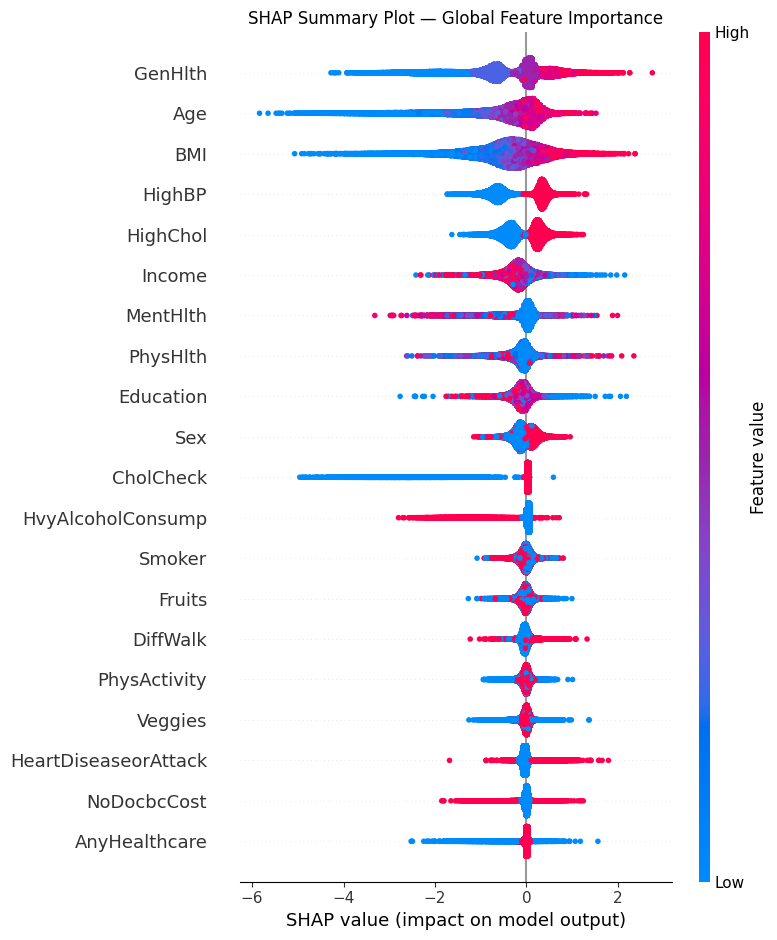

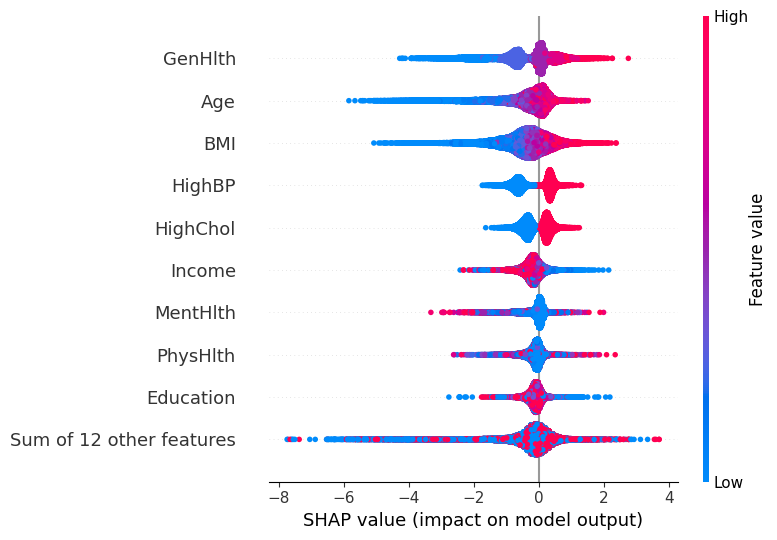

Top 10 features by mean |SHAP|:
GenHlth      0.6741
Age          0.6185
BMI          0.6157
HighBP       0.5152
HighChol     0.3450
Income       0.2642
MentHlth     0.2287
PhysHlth     0.2062
Education    0.1714
Sex          0.1698
dtype: float32


In [44]:
# Refit XGBoost on full balanced training set
best_xgb.fit(X_tr_bal, y_tr_bal)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=ALL_FEATURES, show=False)
plt.title('SHAP Summary Plot — Global Feature Importance')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot
shap_explanation = shap.Explanation(values=shap_values,
                                     base_values=explainer.expected_value,
                                     data=X_test.values,
                                     feature_names=ALL_FEATURES)
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_explanation, show=False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Global feature importance ranking
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=ALL_FEATURES)
mean_shap = mean_shap.sort_values(ascending=False)
print('Top 10 features by mean |SHAP|:')
print(mean_shap.head(10).round(4))

### 4.2 — Dependence Plots (BMI & Age)

<Figure size 800x500 with 0 Axes>

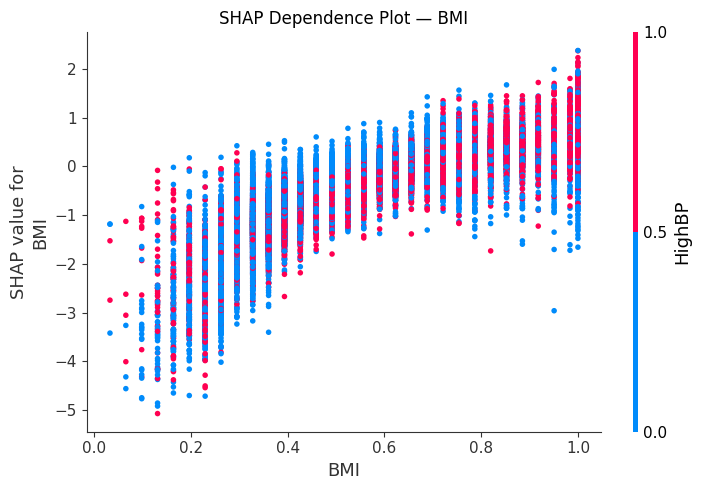

<Figure size 800x500 with 0 Axes>

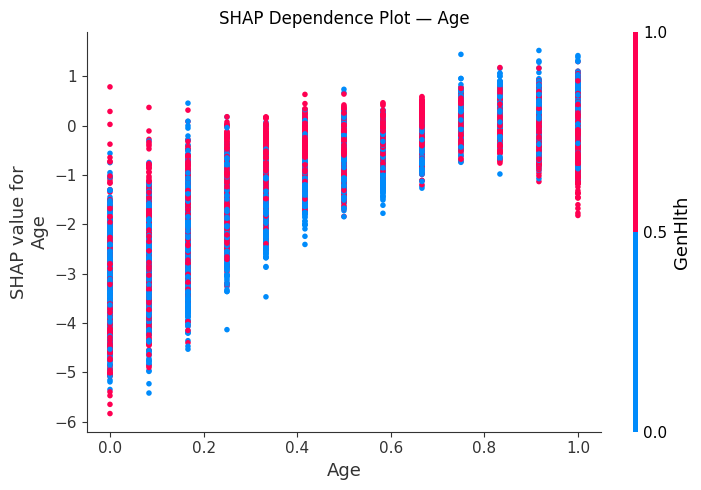

In [45]:
for feat in ['BMI', 'Age']:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feat, shap_values, X_test,
                         feature_names=ALL_FEATURES, show=False)
    plt.title(f'SHAP Dependence Plot — {feat}')
    plt.tight_layout()
    plt.savefig(SAVE_PATH + f'shap_dependence_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 4.3 — Hypothesis Verification (Core Contribution)

In [46]:
shap_df = pd.DataFrame(shap_values, columns=ALL_FEATURES, index=X_test.index)
CONFIRM_THRESHOLD = 0.50   # 50% relative increase → confirmed
SENSITIVITY_THRESHOLD = 0.30  # sensitivity check

verification_results = []

for i, h in enumerate(hypotheses_final, 1):
    orig_feat = h['test_orig_feat']   # original feature name for SHAP (e.g. 'BMI')
    context_items = h['context']      # ARM context items (e.g. ['HighBP_1', 'CholCheck_1'])

    if orig_feat not in shap_df.columns:
        print(f'H{i}: {orig_feat} not in SHAP columns, skipping.')
        continue

    # Population mean SHAP for test feature
    pop_mean = shap_df[orig_feat].mean()

    # Build subgroup mask from context items
    # Context items are ARM names like 'HighBP_1', 'CholCheck_1'
    # Map back to original feature names and filter X_test
    mask = pd.Series([True] * len(X_test), index=X_test.index)
    for ctx_item in context_items:
        ctx_orig = None
        for prefix, orig in ARM_TO_ORIG.items():
            if ctx_item.startswith(prefix):
                ctx_orig = orig
                break
        if ctx_orig and ctx_orig in X_test.columns:
            # Binary features: filter where value == 1 (scaled = 1.0)
            if ctx_item.endswith('_1') and ctx_orig in BINARY_FEATURES:
                mask = mask & (X_test[ctx_orig] == 1.0)

    subgroup = shap_df[mask]
    if len(subgroup) < 50:
        print(f'H{i}: Subgroup too small ({len(subgroup)} records), skipping.')
        continue

    sub_mean = subgroup[orig_feat].mean()
    relative_increase = (sub_mean - pop_mean) / abs(pop_mean) if pop_mean != 0 else 0

    confirmed_50 = relative_increase > CONFIRM_THRESHOLD
    confirmed_30 = relative_increase > SENSITIVITY_THRESHOLD

    result = {
        'Hypothesis': f'H{i}',
        'Test_Feature': orig_feat,
        'ARM_Item': h['test_arm_item'],
        'Context': str(context_items),
        'Subgroup_N': len(subgroup),
        'Pop_mean_SHAP': round(pop_mean, 5),
        'Subgroup_mean_SHAP': round(sub_mean, 5),
        'Relative_increase': round(relative_increase, 4),
        'Confirmed_50pct': confirmed_50,
        'Confirmed_30pct': confirmed_30,
        'Is_Behavioral': h.get('is_behavioral', False)
    }
    verification_results.append(result)

    status = 'CONFIRMED ✓' if confirmed_50 else 'REJECTED ✗'
    print(f'H{i} [{orig_feat}]: pop_mean={pop_mean:.5f}, sub_mean={sub_mean:.5f}, '
          f'relative_increase={relative_increase:.1%} → {status}')

verif_df = pd.DataFrame(verification_results)
verif_df.to_csv(SAVE_PATH + 'hypothesis_verification.csv', index=False)
print('\nVerification results saved.')

H1 [BMI]: pop_mean=-0.40169, sub_mean=-0.26083, relative_increase=35.1% → REJECTED ✗
H2 [DiffWalk]: pop_mean=-0.01256, sub_mean=-0.00405, relative_increase=67.8% → CONFIRMED ✓
H3 [HighChol]: pop_mean=-0.07333, sub_mean=-0.06369, relative_increase=13.1% → REJECTED ✗
H4 [GenHlth]: pop_mean=-0.36807, sub_mean=-0.09779, relative_increase=73.4% → CONFIRMED ✓

Verification results saved.


### 4.4 — ARM–SHAP Jaccard Cross-Check

In [47]:
# Top 10 SHAP features
top10_shap = set(mean_shap.head(10).index)

# Features in top 15 ARM rules
top15_rules = rules_filtered.head(15)
arm_features_raw = set()
for _, row in top15_rules.iterrows():
    for item in row['antecedents']:
        for col in ALL_FEATURES:
            if col in item:
                arm_features_raw.add(col)

jaccard = len(top10_shap & arm_features_raw) / len(top10_shap | arm_features_raw)

print('Top 10 SHAP features:', sorted(top10_shap))
print('Features in top 15 ARM rules:', sorted(arm_features_raw))
print(f'Intersection: {sorted(top10_shap & arm_features_raw)}')
print(f'Jaccard similarity: {jaccard:.4f}')
print('Note: Feature-level Jaccard inflates overlap; interpret with caution.')

Top 10 SHAP features: ['Age', 'BMI', 'Education', 'GenHlth', 'HighBP', 'HighChol', 'Income', 'MentHlth', 'PhysHlth', 'Sex']
Features in top 15 ARM rules: ['AnyHealthcare', 'BMI', 'CholCheck', 'DiffWalk', 'GenHlth', 'HighBP', 'HighChol']
Intersection: ['BMI', 'GenHlth', 'HighBP', 'HighChol']
Jaccard similarity: 0.3077
Note: Feature-level Jaccard inflates overlap; interpret with caution.


### 4.5 — Youth Sub-Analysis (Age 18–44)

Youth subset: 10377 records, 946 At-Risk (9.1%)

Top 10 — Full population vs Youth:
           Full_pop_rank  Full_pop_SHAP  Youth_SHAP
GenHlth                1        0.67409     0.91938
Age                    2        0.61846     1.94945
BMI                    3        0.61572     0.74671
HighBP                 4        0.51518     0.57011
HighChol               5        0.34499     0.43539
Income                 6        0.26418     0.37540
MentHlth               7        0.22865     0.38663
PhysHlth               8        0.20617     0.26708
Education              9        0.17141     0.22870
Sex                   10        0.16976     0.15924


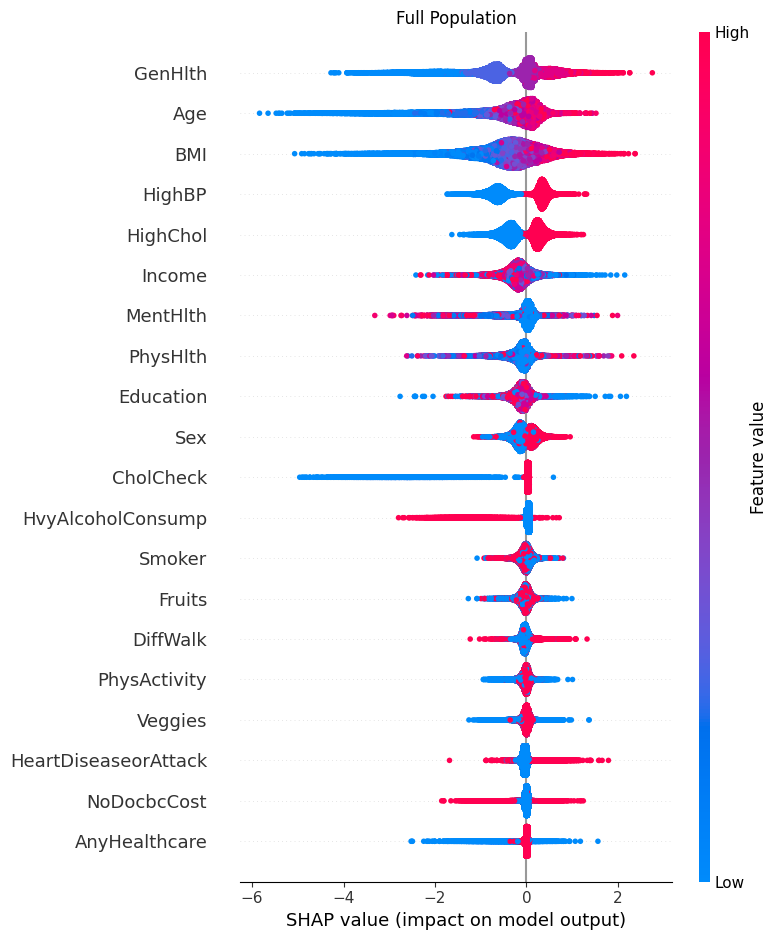

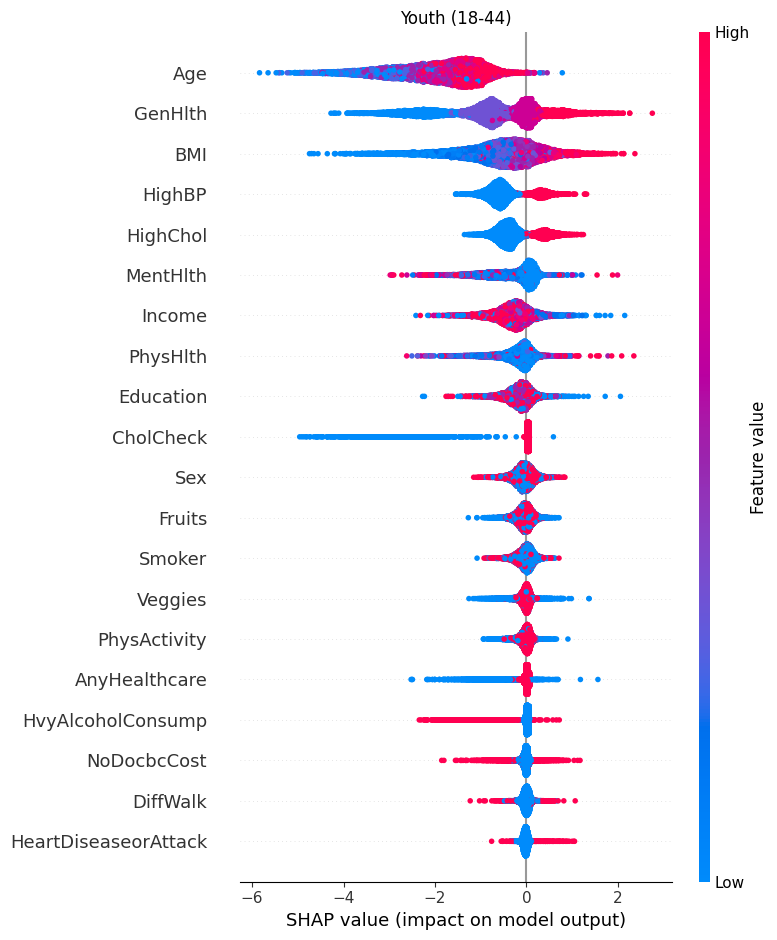

In [50]:
# Age codes 1-5 = 18-44 per BRFSS codebook
youth_mask = X_test['Age'] <= (5 - 1) / 12  # Age was scaled: code 5 → (5-1)/(13-1)
# More robust: use original age from df_A_scaled
age_threshold = (5 - df_A['Age'].min()) / (df_A['Age'].max() - df_A['Age'].min())
youth_mask = X_test['Age'] <= age_threshold

X_youth = X_test[youth_mask]
y_youth = y_test[youth_mask]
shap_youth = shap.TreeExplainer(best_xgb).shap_values(X_youth)

print(f'Youth subset: {len(X_youth)} records, {y_youth.sum()} At-Risk ({y_youth.mean()*100:.1f}%)')

# Compare feature importance: full vs youth
mean_shap_youth = pd.Series(np.abs(shap_youth).mean(axis=0), index=ALL_FEATURES).sort_values(ascending=False)

comparison = pd.DataFrame({
    'Full_pop_rank': range(1, len(mean_shap)+1),
    'Full_pop_SHAP': mean_shap.values,
    'Youth_SHAP': mean_shap_youth.reindex(mean_shap.index).values
}, index=mean_shap.index)

print('\nTop 10 — Full population vs Youth:')
print(comparison.head(10).round(5))
comparison.to_csv(SAVE_PATH + 'youth_shap_comparison.csv')

# shap.summary_plot không hỗ trợ ax parameter — dùng 2 figure riêng
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, feature_names=ALL_FEATURES, show=False)
plt.title('Full Population')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_youth_full_pop.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_youth, X_youth, feature_names=ALL_FEATURES, show=False)
plt.title('Youth (18-44)')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_youth_18_44.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SUMMARY — Final Results

In [51]:
print('='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)

print('\n[1] Model Comparison:')
print(results_df[['Model','Recall','Macro_F1','AUC_ROC','MCC']].to_string(index=False))

print('\n[2] Leakage Sensitivity:')
print(leakage_df[['Model','Recall','Macro_F1']].to_string(index=False))

print('\n[3] Hypothesis Verification:')
if len(verification_results) > 0:
    print(verif_df[['Hypothesis','Test_Feature','Relative_increase','Confirmed_50pct']].to_string(index=False))

print(f'\n[4] ARM-SHAP Jaccard: {jaccard:.4f}')
print(f'[5] Best balancing strategy: {BEST_STRATEGY}')
print('\nAll outputs saved to:', SAVE_PATH)

FINAL RESULTS SUMMARY

[1] Model Comparison:
             Model  Recall  Macro_F1  AUC_ROC    MCC
LogisticRegression  0.7458    0.6941   0.8070 0.4189
      DecisionTree  0.7925    0.7839   0.8215 0.5780
     XGBoost_tuned  0.8138    0.7303   0.8481 0.4958
    LightGBM_tuned  0.6133    0.7109   0.8141 0.4228
RandomForest_tuned  0.7000    0.7171   0.8235 0.4454
        SoftVoting  0.7328    0.7336   0.8441 0.4801

[2] Leakage Sensitivity:
                    Model  Recall  Macro_F1
           Variant_A_full  0.8138    0.7303
     Variant_B_no_leakage  0.8066    0.7038
Variant_C_behavioral_only  0.8375    0.6118

[3] Hypothesis Verification:
Hypothesis Test_Feature  Relative_increase  Confirmed_50pct
        H1          BMI             0.3507            False
        H2     DiffWalk             0.6775             True
        H3     HighChol             0.1315            False
        H4      GenHlth             0.7343             True

[4] ARM-SHAP Jaccard: 0.3077
[5] Best balancing str